In [2]:
# Vectors & Matrices in Python

from numpy import array

ket0 = array([1, 0])
ket1 = array([0, 1])

ket0 / 2 + ket1 / 2 # Taking average of ket0 and ket1

array([0.5, 0.5])

In [3]:
# Matrices & Operations

M1 = array([[1, 1], [0, 0]])
M2 = array([[1, 1], [1, 0]])

M1 / 2 + M2 / 2 

array([[1. , 1. ],
       [0.5, 0. ]])

In [4]:
# Matrix Multiplication using matmul

from numpy import matmul 

display(matmul(M1, ket1))
display(matmul(M1, M2))
display(matmul(M2, M1))

array([1, 0])

array([[2, 1],
       [0, 0]])

array([[1, 1],
       [1, 1]])

### States, Measurements and Operations

##### Defining and Displaying State Vectors

Qiskits ``Statevector`` class provides functionality for defining and manipulating quantum state vectors. 

In [5]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1/sqrt(2), 1/sqrt(2)])
v = Statevector([(1 + 2.0j)/3, -2/3])
w = Statevector([1/3, 2/3])

print("State vectors u, v, and w have been defined")

State vectors u, v, and w have been defined


The ``Statevector`` class provides a ``draw`` method for displaying state vectors including ``latex`` and ``text`` options for different visualizations

In [6]:
display(u.draw("latex"))
display(v.draw("text"))

<IPython.core.display.Latex object>

[ 0.33333333+0.66666667j,-0.66666667+0.j        ]

The ``Statevector`` class also includes the ``is_valid`` method, which checks to see if a given vector is a valid quantum state vector (it has a euclidean norm = 1)

In [7]:
display(u.is_valid())
display(w.is_valid())

True

False

Simulating measurements using the ``measure`` method from the ``Statevector`` class

In [12]:
v = Statevector([(1+2.0j)/3, -2/3])
v.draw("latex")

<IPython.core.display.Latex object>

Running the ``measure`` method stimulates a standard basis measurement. It returns the result of that measurement, plus the new quantum state of our system after that measurement

In [23]:
v.measure()

('0',
 Statevector([0.4472136+0.89442719j, 0.       +0.j        ],
             dims=(2,)))

Measurements are probabilistic, so the same method can return different results. If the measurement yields 0 the quantum state vector after the measurements takes place to be 
$$ \frac{1+2i}{\sqrt{5}}|0\rangle $$
(rather than $|0\rangle$).

If the measurement yields 1, the quantum state becomes $$-|1\rangle$$ (rather than $|1\rangle$). 

In both cases the alternatives are equivalent -- they are said to _differ_ by a _global phase_ because one is equal to the other multiplied by a complex number on the unit circle. 

As an aside, ``Statevector`` will throw an error if the ``measure`` method is applied to an invalid quantum state vector. 

``Statevector`` also comes with a ``sample_counts`` method that allows for the simulation of any # of measurements on the system. We can use ``plot histogram`` to visualize the results. 



{'0': 544, '1': 456}

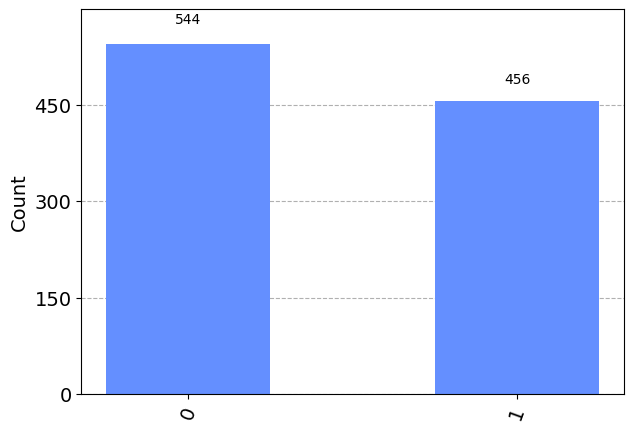

In [25]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
display(statistics)
plot_histogram(statistics)

### Peforming Operations with ``Operator`` and ``Statevector`` 

Unitary operations can be defined and performed on state vectors in Qiskit using the ``Operator`` class

In [29]:
from qiskit.quantum_info import Operator

X = Operator([[0, 1], [1, 0]])
Y = Operator([[0, -1.0j], [1.0j, 0]])
Z = Operator([[1, 0], [0, -1]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(Z)

v.draw("latex")

<IPython.core.display.Latex object>

Looking ahead towards Quantum Circuits

We can define Quantum Circuits (which right now will simply be a sequence of unitary operations performed on a single qubit)

In [30]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.t(0)
circuit.z(0)

circuit.draw()

┌───┐┌───┐┌───┐┌───┐┌───┐
q: ┤ H ├┤ T ├┤ H ├┤ T ├┤ Z ├
   └───┘└───┘└───┘└───┘└───┘

The operations are applied sequentially. 

Let us first initialize a starting quantum state vector and evolve that state according to the above sequence of operations. 

In [31]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
v.draw("latex")

<IPython.core.display.Latex object>

Finally let us simulate the result of running this experiment (i.e. preparing the state $|0\rangle$, applying the sequence of operations represented by the circuit and measuring) 4000 times.  

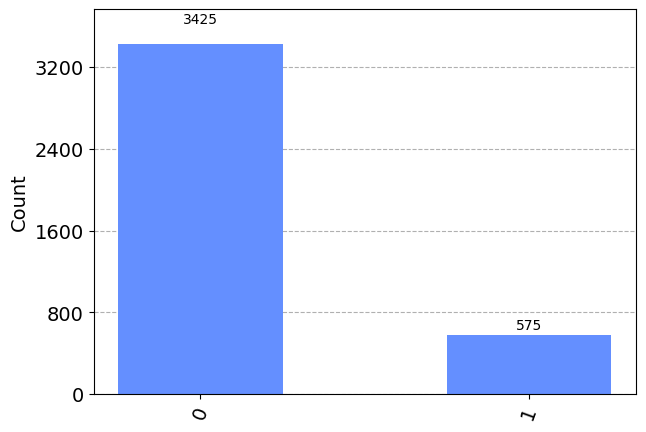

In [32]:
statistics = v.sample_counts(4000)
plot_histogram(statistics)